# 5. Model Evaluation

*Proposal section 3.2.4.* Evaluates the tuned models from `04_model_training` on the held-out test sets, checks them against real fraud outcomes, and produces the report figures.

## Setup

Runs locally or in Google Colab. In Colab it mounts Google Drive, copies this repo's code from GitHub, and points `data/` at **My Drive** (raw files in the Drive root, outputs in `My Drive/processed`) and `models/` at `My Drive/models`, so outputs survive between sessions.

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_URL = "https://github.com/JamieNguru/169421-escrow-based-wallet-and-payment-system.git"
    if not Path("/content/repo").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", "dev", REPO_URL, "/content/repo"], check=True)
    ROOT = Path("/content/repo/trust-scoring-ml")
    DRIVE = Path("/content/drive/MyDrive")
    (DRIVE / "models").mkdir(exist_ok=True)
    for name, target in [("data", DRIVE), ("models", DRIVE / "models")]:
        if not (ROOT / name).exists():
            (ROOT / name).symlink_to(target, target_is_directory=True)
else:
    ROOT = Path.cwd().parent

sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import classification_report

from src.evaluate import evaluate_model
from src.external_validation import correlate_trust_with_real_fraud, load_client_fraud_rates
from src.feature_engineering import TRUST_LEVELS, add_client_trust_label, add_worker_trust_label
from src.generate_figures import generate_role_figures
from src.model_io import load_model
from src.train import (
    CLIENT_FEATURE_COLUMNS,
    MODEL_VERSION,
    WORKER_FEATURE_COLUMNS,
    split_client_dataset,
    split_worker_dataset,
)

## Load the models and the held-out test sets

The split is rebuilt with the same seed as in training, so these are exactly the rows the models never saw.

In [3]:
worker_dataset = pd.read_csv(PROCESSED_DIR / "worker_features.csv")
client_dataset = pd.read_csv(PROCESSED_DIR / "client_features.csv")

_, worker_X_test, _, worker_y_test = split_worker_dataset(worker_dataset)
_, client_X_test, _, client_y_test = split_client_dataset(client_dataset)

models = {role: load_model(role, MODEL_VERSION) for role in ["worker", "client"]}
for role, model in models.items():
    print(f"{role}: {model.n_estimators} trees, max_depth={model.max_depth}")

worker: 400 trees, max_depth=None
client: 400 trees, max_depth=10


## Test-set metrics

In [4]:
pd.DataFrame({
    "worker": evaluate_model(models["worker"], worker_X_test, worker_y_test),
    "client": evaluate_model(models["client"], client_X_test, client_y_test),
}).round(3)

,worker,client
accuracy,0.924,0.873
precision,0.924,0.873
recall,0.924,0.873
f1,0.923,0.873
roc_auc,0.988,0.979


In [5]:
for role, X_test, y_test in [("Worker", worker_X_test, worker_y_test), ("Client", client_X_test, client_y_test)]:
    print(f"{role} model\n" + classification_report(y_test, models[role.lower()].predict(X_test), labels=TRUST_LEVELS, digits=3))

Worker model
              precision    recall  f1-score   support

         Low      0.947     0.900     0.923        40
      Medium      0.895     0.872     0.883        39
        High      0.930     1.000     0.964        40

    accuracy                          0.924       119
   macro avg      0.924     0.924     0.923       119
weighted avg      0.924     0.924     0.924       119

Client model
              precision    recall  f1-score   support

         Low      0.907     0.929     0.918        42
      Medium      0.810     0.810     0.810        42
        High      0.902     0.881     0.892        42

    accuracy                          0.873       126
   macro avg      0.873     0.873     0.873       126
weighted avg      0.873     0.873     0.873       126



## External validation against real fraud

The trust labels are derived from the same features the models use, so the scores above show the pipeline works rather than real-world predictive power. `train_fraud_labels.json` holds real, independently recorded fraud outcomes that nothing else in the pipeline uses. If the trust features carry real signal, Low-trust users should show more real fraud than High-trust users.

One catch: each user has a similar number of fraud cases however much they transact, so a user's fraud *rate* falls mechanically as their transaction volume rises. Any feature tied to volume, such as time between transactions, will seem to predict fraud for that reason alone.

In [6]:
fraud_rates = load_client_fraud_rates(DATA_DIR)

fraud_results = {
    "worker": correlate_trust_with_real_fraud(add_worker_trust_label(worker_dataset), fraud_rates),
    "client": correlate_trust_with_real_fraud(add_client_trust_label(client_dataset), fraud_rates),
}

pd.DataFrame([
    {
        "model": role,
        "users": result["n_clients"],
        "trust vs fraud (Spearman)": result["spearman_correlation"],
        "p": result["p_value"],
        "trust vs fraud, volume held constant": result["partial_spearman_correlation"],
        "p (volume held constant)": result["partial_p_value"],
        "trust vs volume": result["trust_volume_correlation"],
    }
    for role, result in fraud_results.items()
]).set_index("model").round(4)

,users,trust vs fraud (Spearman),p,"trust vs fraud, volume held constant",p (volume held constant),trust vs volume
model,,,,,,
worker,592,-0.1393,0.0007,-0.0221,0.5917,0.2840
client,627,-0.0980,0.0140,0.0038,0.9239,0.2663


### Fraud rate within volume bands

Users are split into four equal groups by how many fraud-labelled transactions they have. Within each group, volume is roughly the same, so differences between trust levels there aren't driven by volume.

In [7]:
for role, result in fraud_results.items():
    print(f"{role.title()}s: mean real fraud rate (%) by volume band and trust level")
    display((result["mean_real_fraud_rate_by_volume_band"] * 100).round(3))

Workers: mean real fraud rate (%) by volume band and trust level


trust_level,Low,Medium,High
volume_band,,,
Lowest,0.306,0.346,0.252
Lower-middle,0.185,0.177,0.196
Upper-middle,0.140,0.136,0.165
Highest,0.110,0.084,0.093


Clients: mean real fraud rate (%) by volume band and trust level


trust_level,Low,Medium,High
volume_band,,,
Lowest,0.363,0.218,0.253
Lower-middle,0.186,0.228,0.145
Upper-middle,0.122,0.151,0.147
Highest,0.086,0.104,0.118


## Figures

Saved to `reports/figures/` for the write-up.

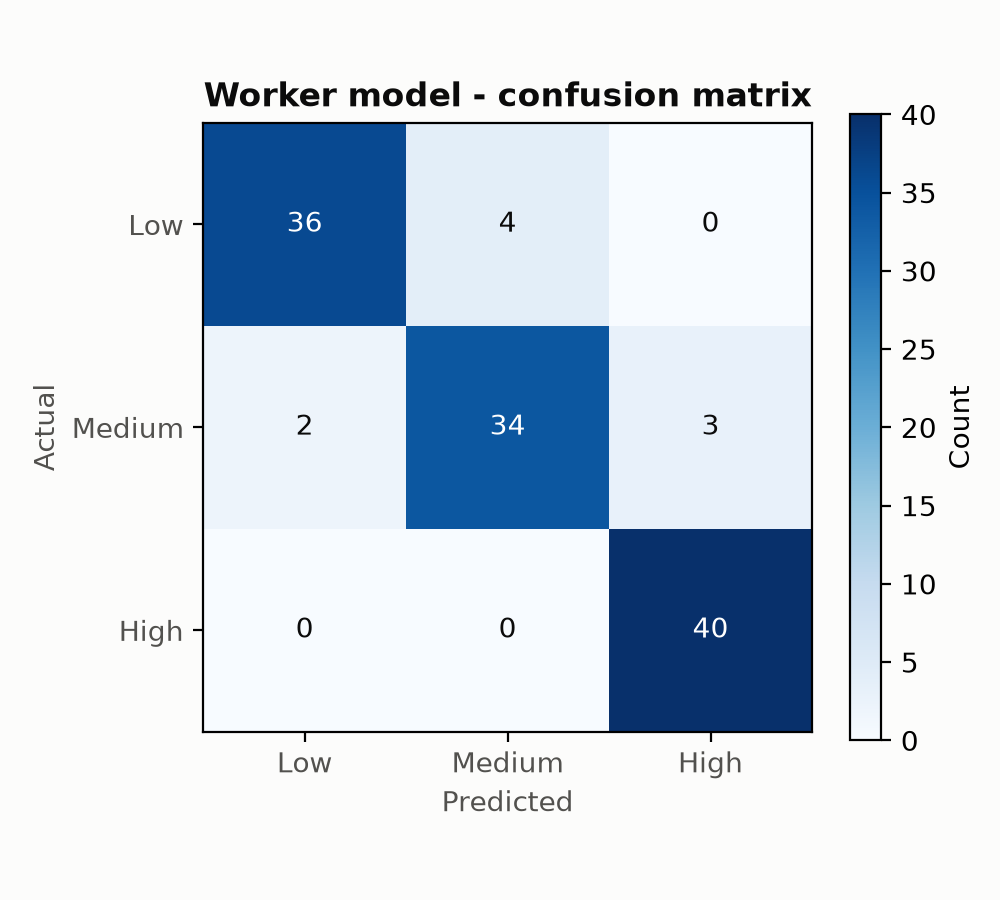

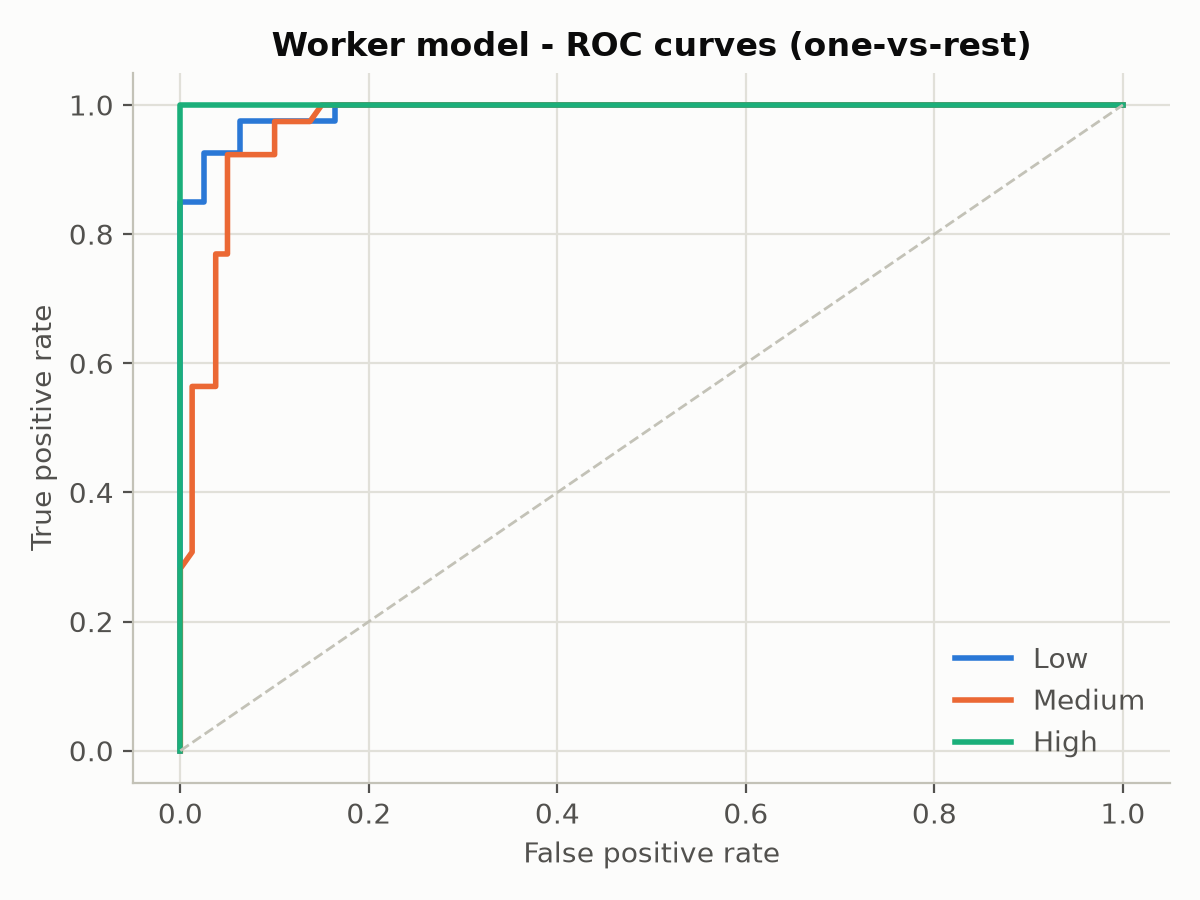

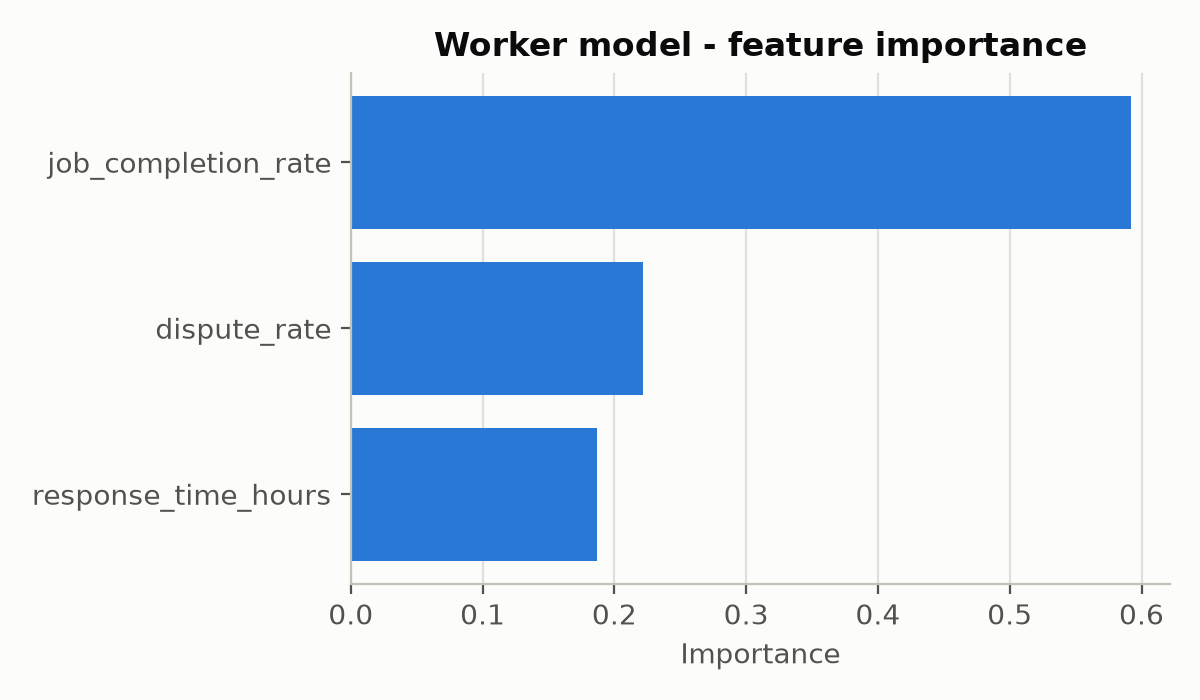

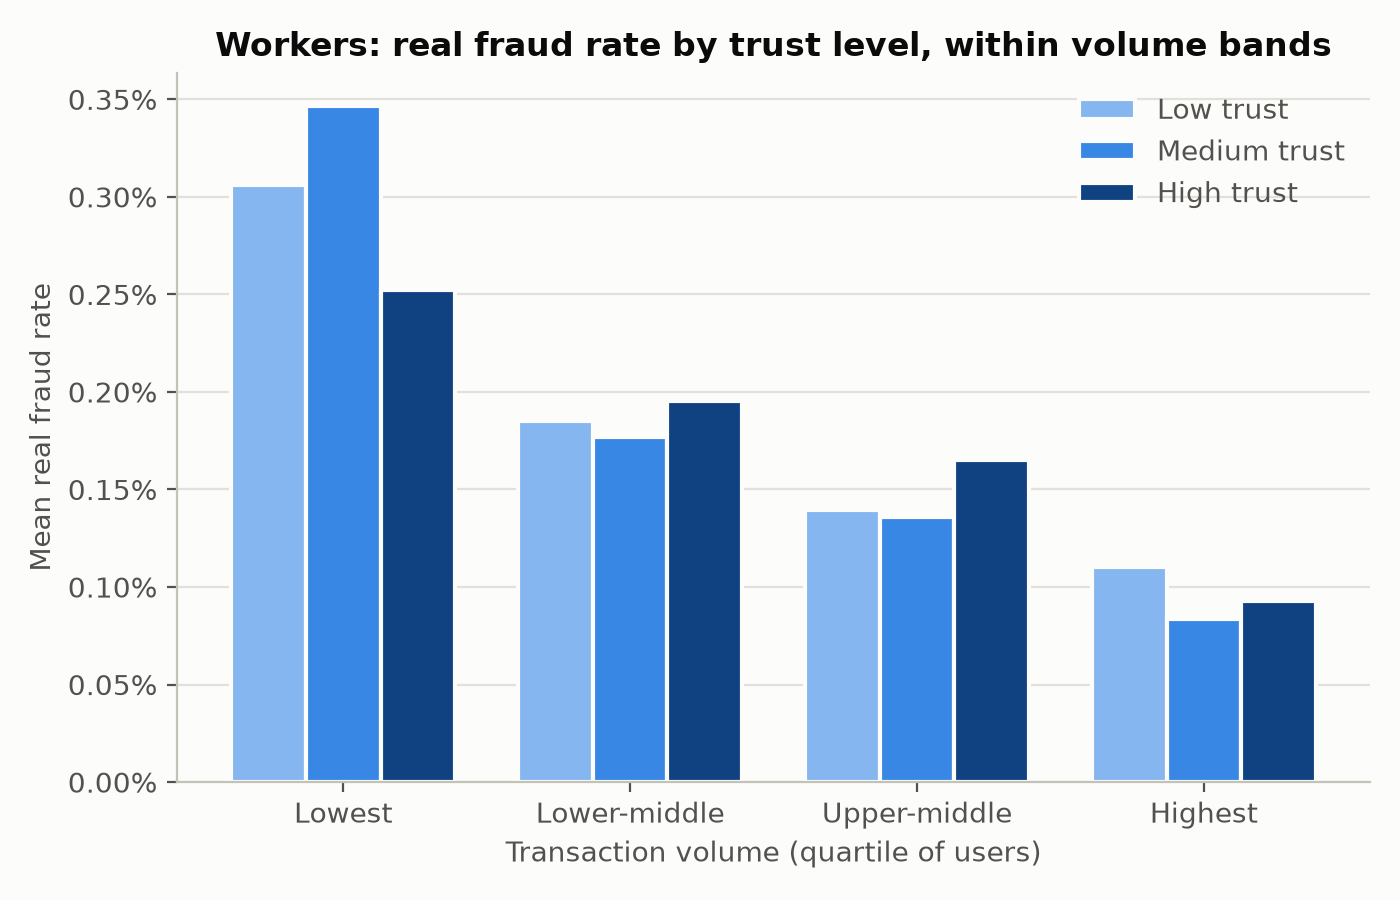

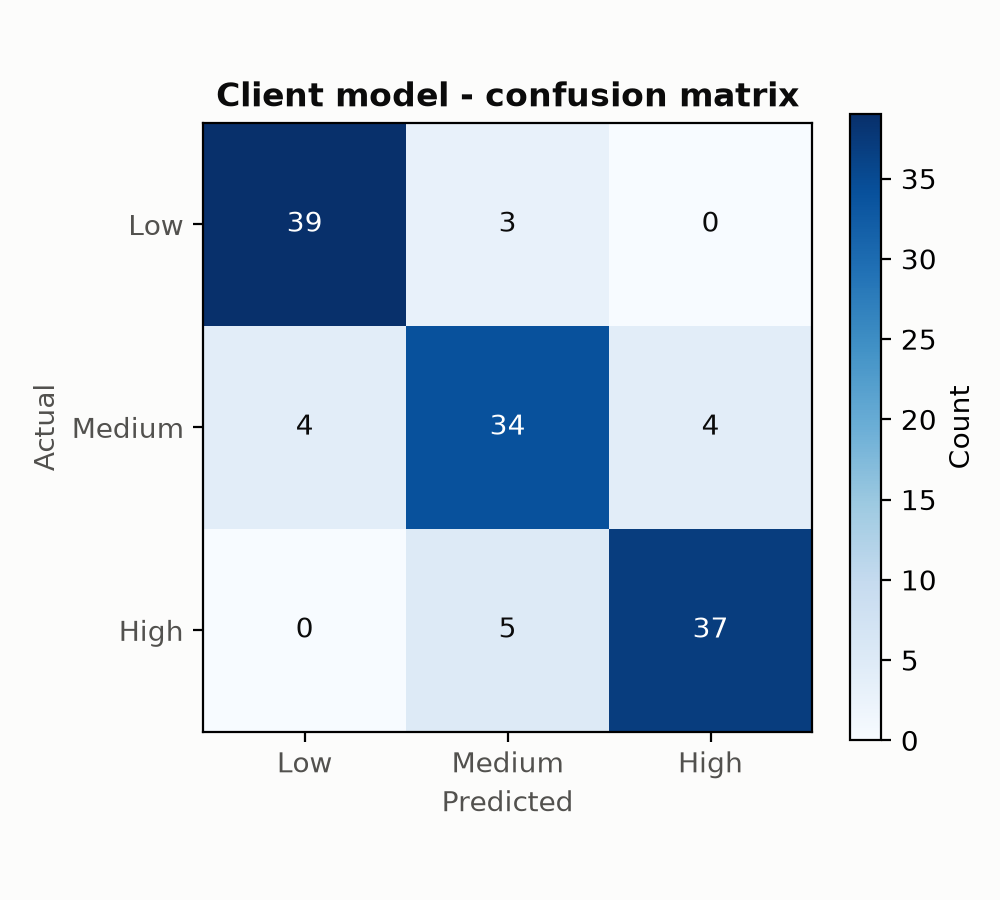

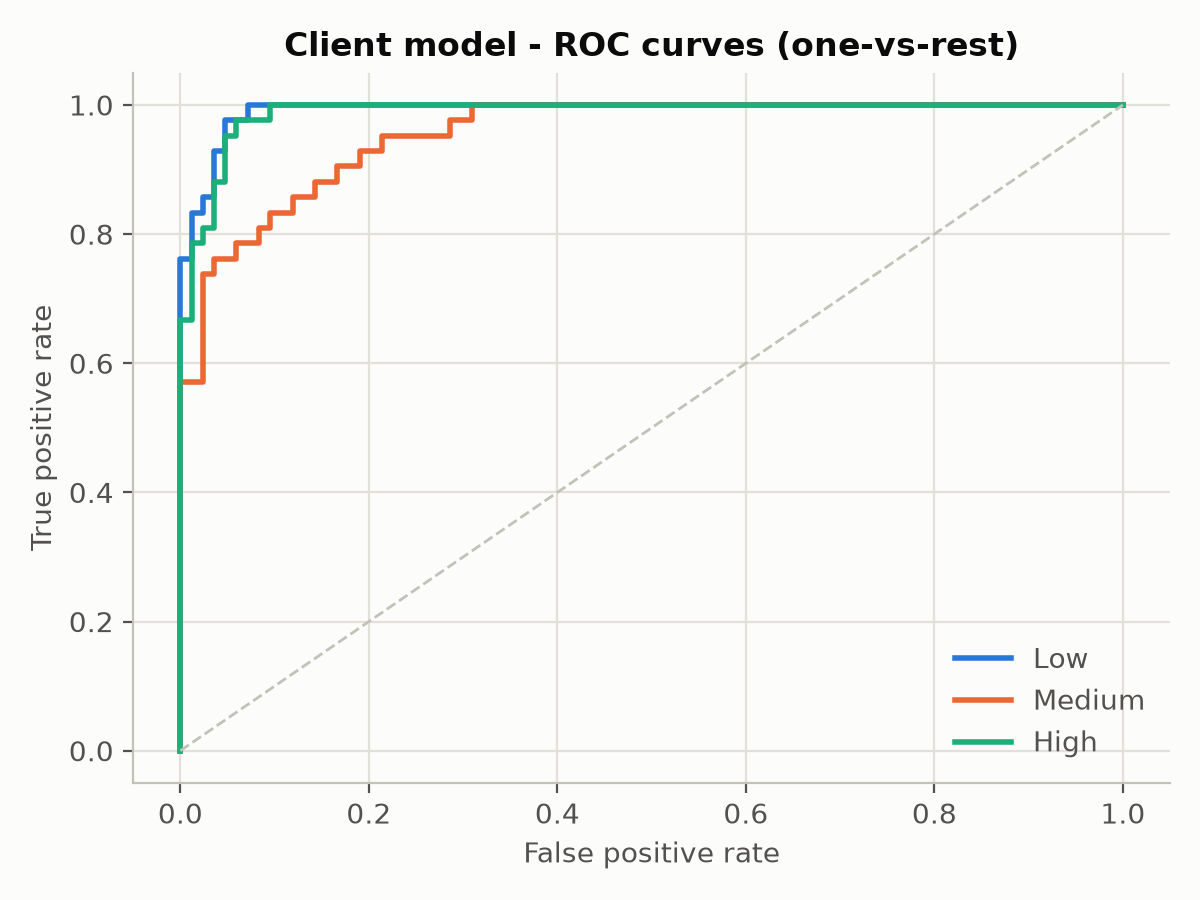

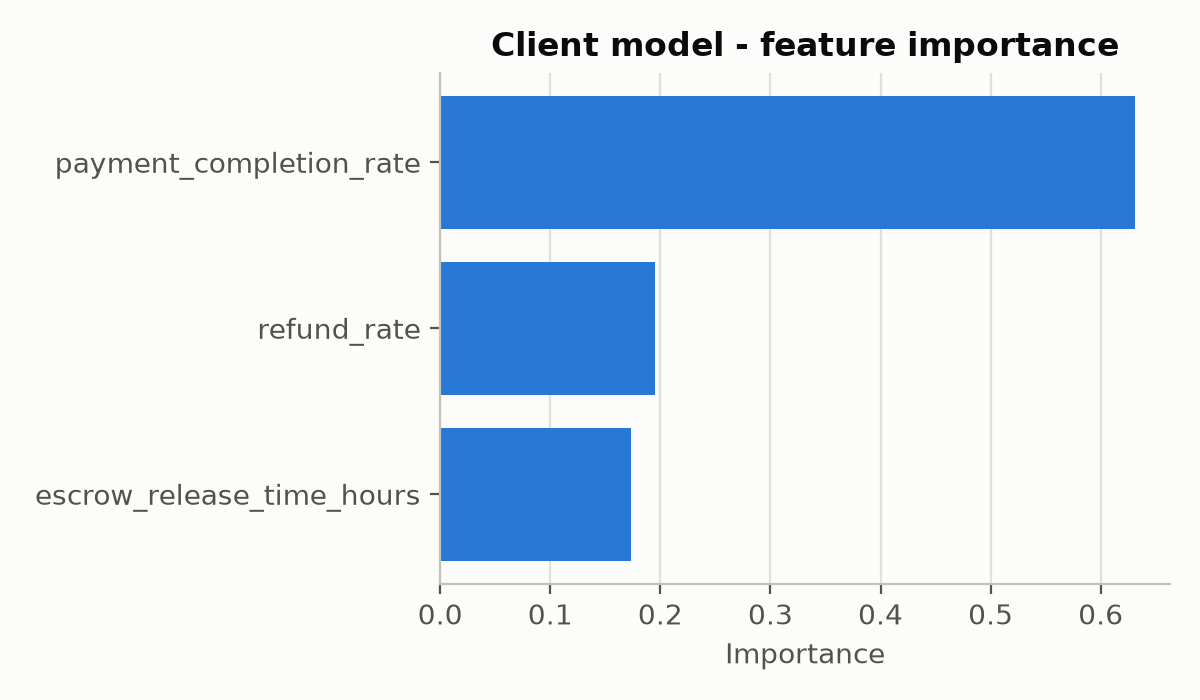

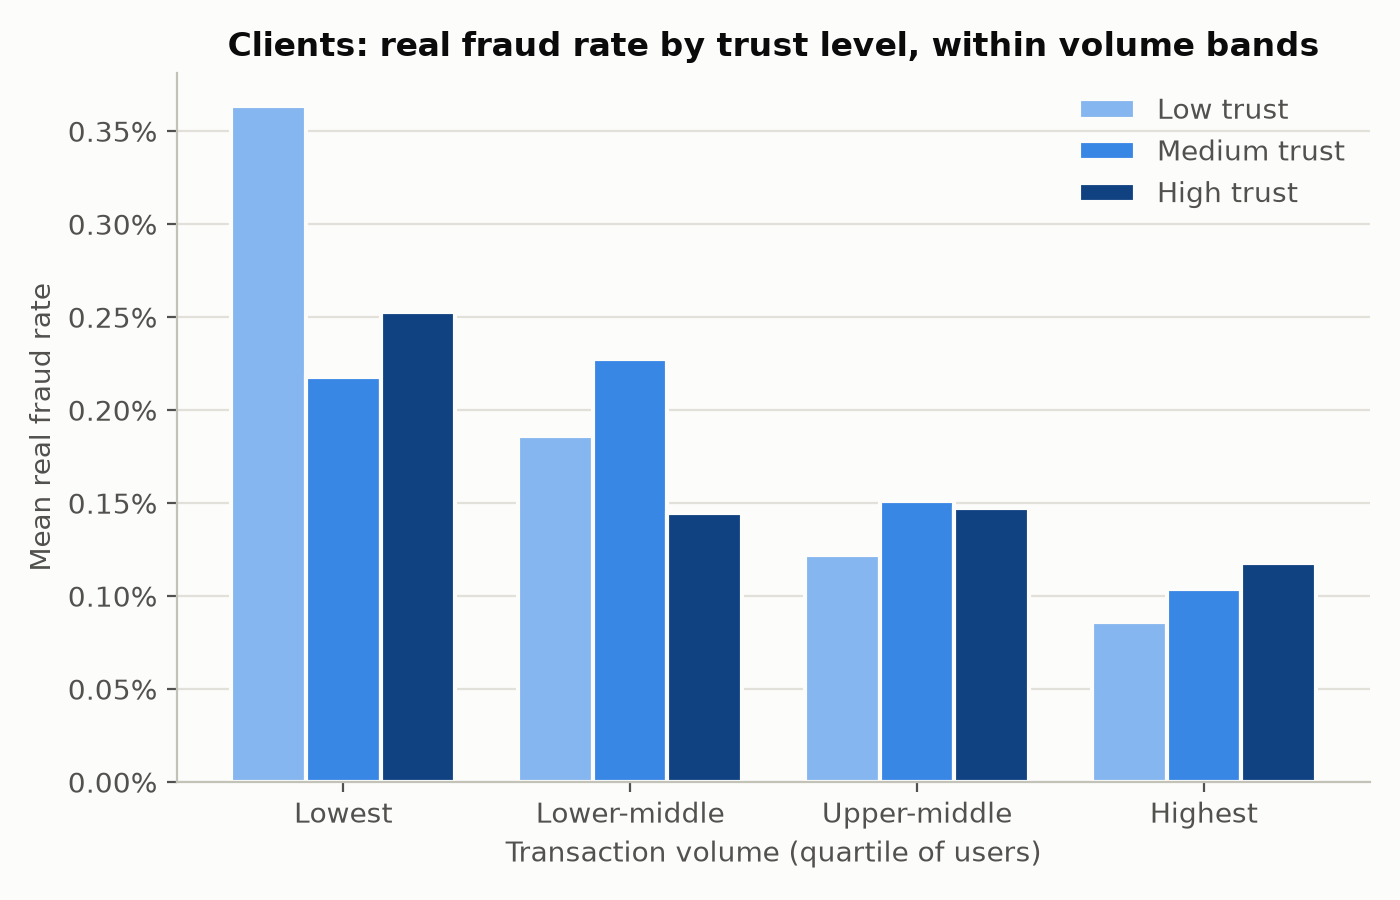

In [8]:
generate_role_figures("Worker", models["worker"], worker_X_test, worker_y_test, WORKER_FEATURE_COLUMNS, fraud_results["worker"], FIGURES_DIR)
generate_role_figures("Client", models["client"], client_X_test, client_y_test, CLIENT_FEATURE_COLUMNS, fraud_results["client"], FIGURES_DIR)

for role in ["worker", "client"]:
    for chart in ["confusion_matrix", "roc_curves", "feature_importance", "fraud_rate_by_trust_and_volume"]:
        display(Image(filename=str(FIGURES_DIR / f"{role}_{chart}.png"), width=480))

## Interpreting the results

- **Test-set scores** (worker accuracy 0.924, client 0.873) show the models learn the trust rule well but not perfectly. Because the rule is built from the same features, these are not evidence of real-world accuracy.
- **The real-fraud check finds no evidence that the trust levels capture trustworthiness.** Trust and fraud look related at first (Spearman -0.14 for workers, -0.10 for clients), but trust also rises with transaction volume (+0.28), and fraud rate falls with volume. Holding volume constant, the relationship disappears (workers -0.02, p = 0.59; clients +0.00, p = 0.92), and within each volume band the three trust levels show no consistent pattern.
- **What this means:** behaviour proxies simulated from card transactions can't validate a trust model for a labour platform. Showing real-world predictive power needs real platform outcomes (completed jobs, disputes, escrow releases), which is future work. A time-based split (issue #48) would test whether past behaviour predicts future fraud in this data.